In [4]:
import numpy as np
import csv

def parse_csv_to_matrix(file_path):
    """
    Parses a CSV file with x, y, z headers and returns a numpy matrix of vectors.
    
    Args:
        file_path (str): Path to the CSV file
        
    Returns:
        numpy.ndarray: Matrix of shape (n_timesteps, 3) where each row is a [x, y, z] vector
    """
    vectors = []
    
    with open(file_path, 'r') as f:
        reader = csv.DictReader(f)
        i = 0 
        flines = f.readlines()
        for row in flines:
            row = row.strip().strip('\n')  # Remove any leading/trailing whitespace
            if i == 0:
                # Skip the header row
                i += 1
                continue
            else:
                valList = row.split(',')
                x = float(valList[0])
                y = float(valList[1])
                z = float(valList[2])
                vectors.append([x, y, z])
            i += 1
    
    return np.array(vectors)

In [18]:
data = None
flines = None
with open('trial5.txt', 'r') as f:
    i = 0 
    flines = f.readlines()
    data = f

In [19]:
flines

[b'x ,y ,z\r\n',
 b'-0.01 ,-0.09 ,-0.09\r\n',
 b'-0.01 ,-0.09 ,-0.09\r\n',
 b'-0.01 ,-0.08 ,-0.07\r\n',
 b'-0.02 ,-0.08 ,-0.06\r\n',
 b'-0.02 ,-0.07 ,-0.05\r\n',
 b'-0.02 ,-0.07 ,-0.05\r\n',
 b'-0.03 ,-0.06 ,-0.04\r\n',
 b'-0.03 ,-0.05 ,-0.03\r\n',
 b'-0.03 ,-0.04 ,-0.02\r\n',
 b'-0.03 ,-0.03 ,-0.02\r\n',
 b'-0.03 ,-0.02 ,-0.02\r\n',
 b'-0.03 ,-0.01 ,-0.01\r\n',
 b'-0.03 ,0.00 ,-0.01\r\n',
 b'-0.03 ,0.01 ,-0.01\r\n',
 b'-0.04 ,0.01 ,-0.01\r\n',
 b'-0.04 ,0.02 ,-0.02\r\n',
 b'-0.03 ,0.03 ,-0.03\r\n',
 b'-0.03 ,0.03 ,-0.03\r\n',
 b'-0.03 ,0.04 ,-0.03\r\n',
 b'-0.03 ,0.04 ,-0.05\r\n',
 b'-0.03 ,0.05 ,-0.05\r\n',
 b'-0.03 ,0.05 ,-0.06\r\n',
 b'-0.03 ,0.05 ,-0.07\r\n',
 b'-0.03 ,0.05 ,-0.08\r\n',
 b'-0.03 ,0.06 ,-0.09\r\n',
 b'-0.03 ,0.05 ,-0.10\r\n',
 b'-0.03 ,0.05 ,-0.11\r\n',
 b'-0.03 ,0.06 ,-0.11\r\n',
 b'-0.03 ,0.05 ,-0.12\r\n',
 b'-0.03 ,0.05 ,-0.12\r\n',
 b'-0.03 ,0.05 ,-0.13\r\n',
 b'-0.03 ,0.05 ,-0.13\r\n',
 b'-0.03 ,0.04 ,-0.16\r\n',
 b'-0.03 ,0.04 ,-0.14\r\n',
 b'-0.03 ,0.03 ,-0.

In [5]:
import matplotlib.pyplot as plt

def plot_acceleration(values, n_timesteps, total_time_period, title):
    time = np.linspace(0, total_time_period, n_timesteps, endpoint=False)

    plt.figure(figsize=(8, 4))
    plt.plot(time, values)
    plt.xlabel("Time")
    plt.ylabel("Acceleration")
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_xyz_from_matrix(matrix, total_time_period):
    n_timesteps = matrix.shape[0]
    plot_acceleration(matrix[:, 0], n_timesteps, total_time_period, "X Acceleration vs Time")
    plot_acceleration(matrix[:, 1], n_timesteps, total_time_period, "Y Acceleration vs Time")
    plot_acceleration(matrix[:, 2], n_timesteps, total_time_period, "Z Acceleration vs Time")

# Example usage:
# matrix = parse_csv_to_matrix(file_path)
# plot_xyz_from_matrix(matrix, total_time_period)

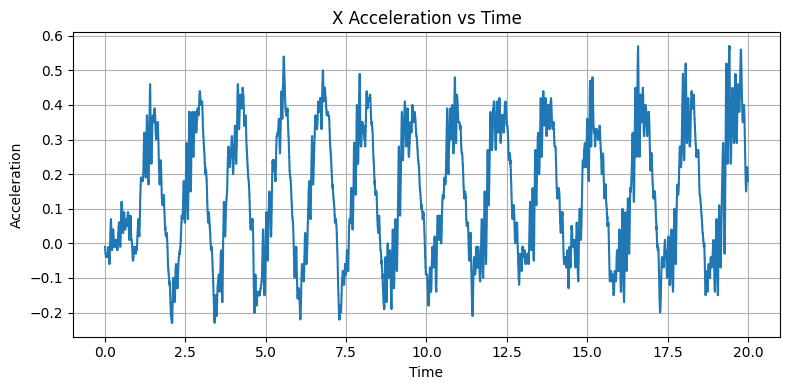

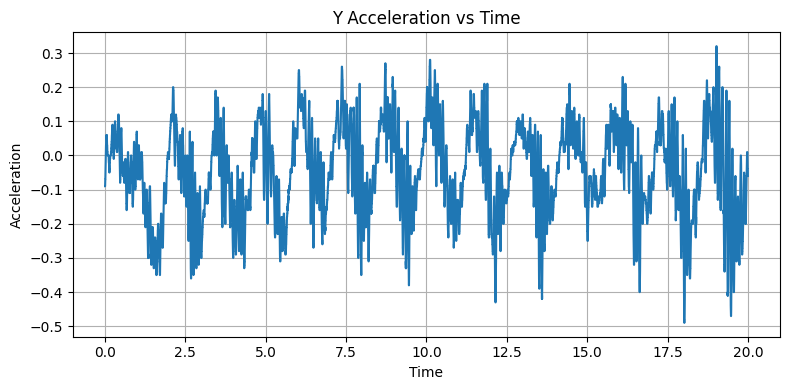

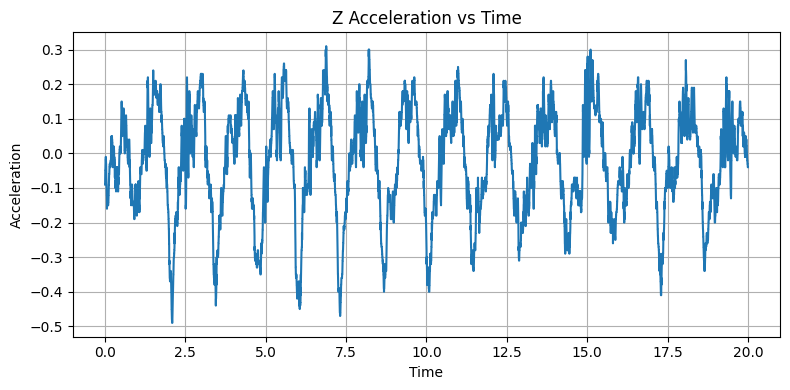

In [21]:
data_vals = parse_csv_to_matrix("trial5.txt")
plot_xyz_from_matrix(data_vals, 20)

In [ ]:
def split_rep_cycles(
    values,
    smooth_window=7,
    start_rise_threshold=None,
    peak_drop_threshold=None,
    recovery_threshold=None,
    min_peak_height=None,
):
    """
    Split a 1D accelerometer time series into rep cycles.

    A rep is detected as:
    1. signal rises from a local low,
    2. reaches a positive peak,
    3. drops from that peak by a threshold,
    4. reaches a negative peak,
    5. rises back up from that negative peak.

    Returns:
        numpy.ndarray: dtype=object array where each element is a 1D numpy array
        containing the values for one rep cycle.
    """
    values = np.asarray(values, dtype=float)
    if values.ndim != 1 or len(values) < 3:
        return np.array([], dtype=object)

    # Light smoothing to reduce noise while keeping original slices in the output.
    if smooth_window > 1:
        kernel = np.ones(smooth_window) / smooth_window
        smoothed = np.convolve(values, kernel, mode="same")
    else: 
        smoothed = values.copy()

    scale = np.std(smoothed)
    if scale == 0:
        return np.array([], dtype=object)

    if start_rise_threshold is None:
        start_rise_threshold = 0.4 * scale
    if peak_drop_threshold is None:
        peak_drop_threshold = 0.4 * scale
    if recovery_threshold is None:
        recovery_threshold = 0.4 * scale
    if min_peak_height is None:
        min_peak_height = 0.5 * scale

    reps = []

    state = "idle"
    start_idx = 0

    local_min_idx = 0
    local_min_val = smoothed[0]

    pos_peak_idx = None
    pos_peak_val = None

    neg_peak_idx = None
    neg_peak_val = None

    for i in range(1, len(smoothed)):
        v = smoothed[i]

        if state == "idle":
            if v < local_min_val:
                local_min_val = v
                local_min_idx = i

            if (v - local_min_val) >= start_rise_threshold:
                start_idx = local_min_idx
                pos_peak_idx = i
                pos_peak_val = v
                state = "looking_for_pos_peak"

        elif state == "looking_for_pos_peak":
            if v > pos_peak_val:
                pos_peak_val = v
                pos_peak_idx = i

            if (pos_peak_val - v) >= peak_drop_threshold and pos_peak_val >= min_peak_height:
                neg_peak_idx = i
                neg_peak_val = v
                state = "looking_for_neg_peak"

        elif state == "looking_for_neg_peak":
            if v < neg_peak_val:
                neg_peak_val = v
                neg_peak_idx = i

            if (v - neg_peak_val) >= recovery_threshold and neg_peak_val <= -min_peak_height:
                reps.append(values[start_idx:i + 1])

                state = "idle"
                local_min_idx = i
                local_min_val = v
                pos_peak_idx = None
                pos_peak_val = None
                neg_peak_idx = None
                neg_peak_val = None

    return np.array(reps, dtype=object)


# Example:
# x_reps = split_rep_cycles(data_vals[:, 0])
# len(x_reps), x_reps[0]

In [ ]:
out = split_rep_cycles(data_vals[:, 0])
len(out), out[0]


(14, array([-0.05, -0.06, -0.05, ..., -0.17, -0.16, -0.14]))

Rep 0: length=1057, first 5 values=[-0.05 -0.06 -0.05 -0.05 -0.05]


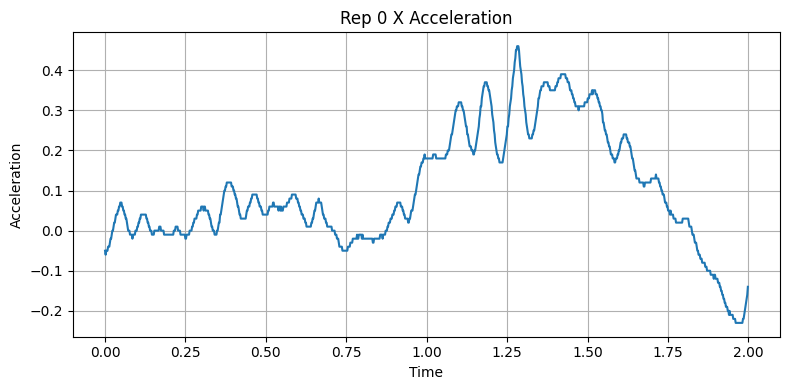

Rep 1: length=685, first 5 values=[-0.17 -0.17 -0.17 -0.17 -0.16]


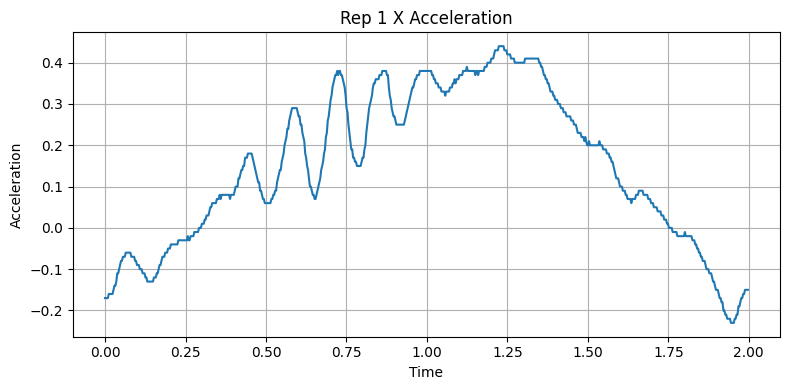

Rep 2: length=643, first 5 values=[-0.21 -0.21 -0.21 -0.21 -0.21]


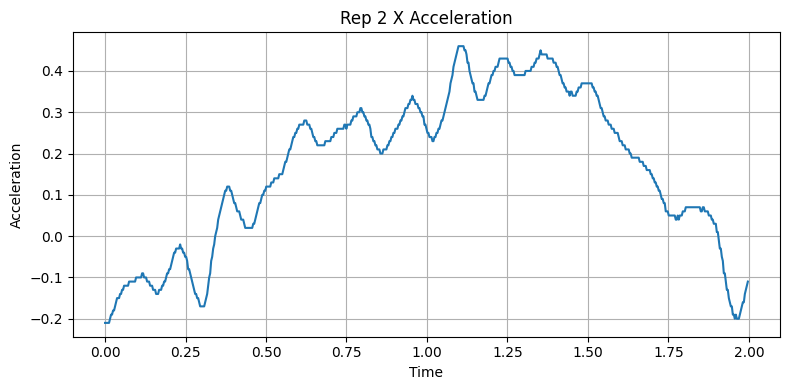

Rep 3: length=650, first 5 values=[-0.18 -0.18 -0.18 -0.18 -0.17]


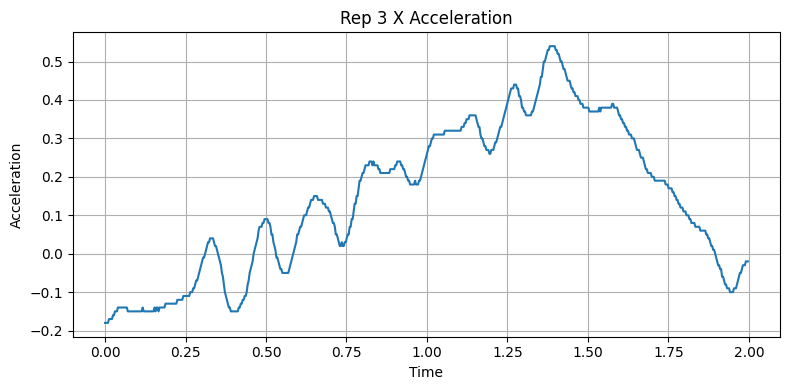

Rep 4: length=690, first 5 values=[-0.22 -0.22 -0.22 -0.21 -0.21]


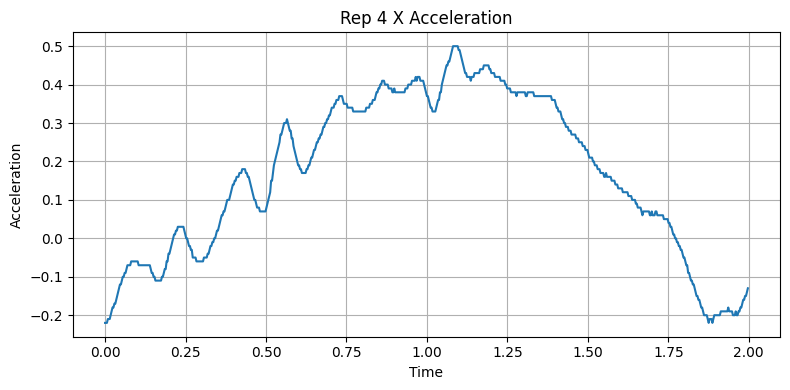

Rep 5: length=721, first 5 values=[-0.13 -0.12 -0.12 -0.12 -0.11]


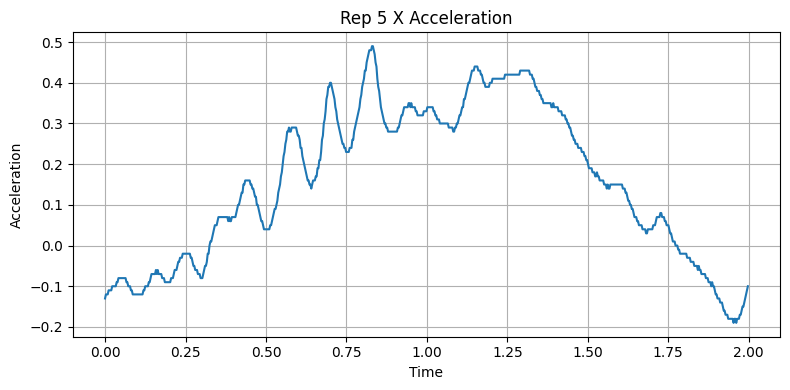

Rep 6: length=717, first 5 values=[-0.17 -0.17 -0.16 -0.15 -0.14]


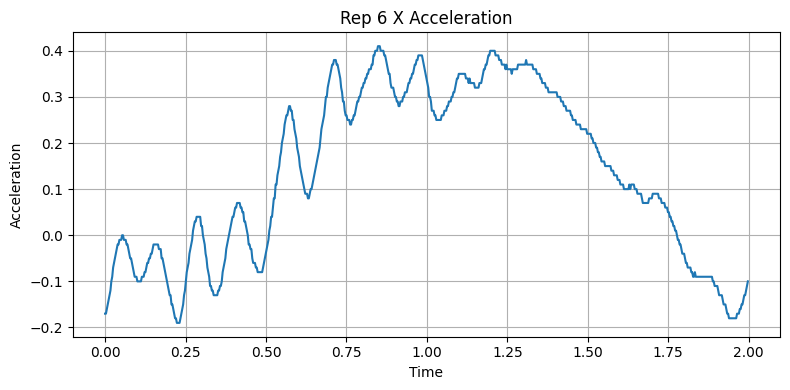

Rep 7: length=704, first 5 values=[-0.14 -0.14 -0.14 -0.14 -0.13]


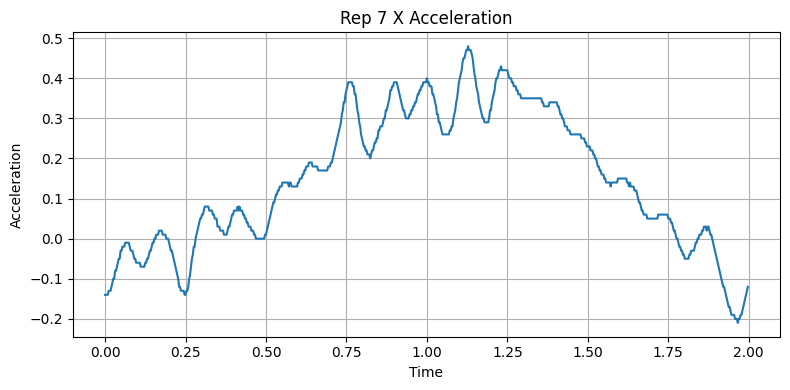

Rep 8: length=780, first 5 values=[-0.12 -0.11 -0.11 -0.1  -0.09]


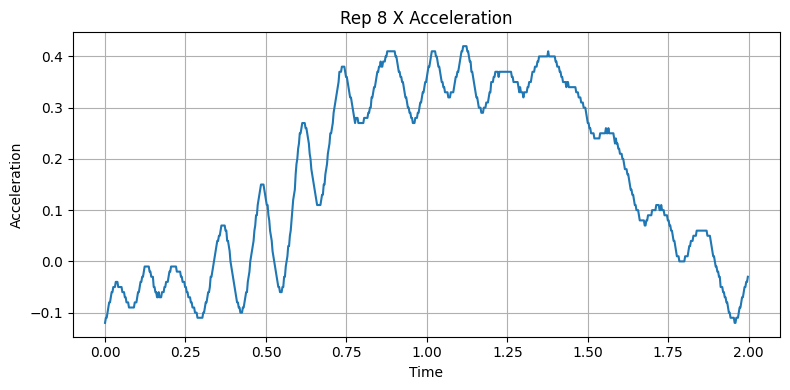

Rep 9: length=793, first 5 values=[-0.08 -0.08 -0.08 -0.08 -0.07]


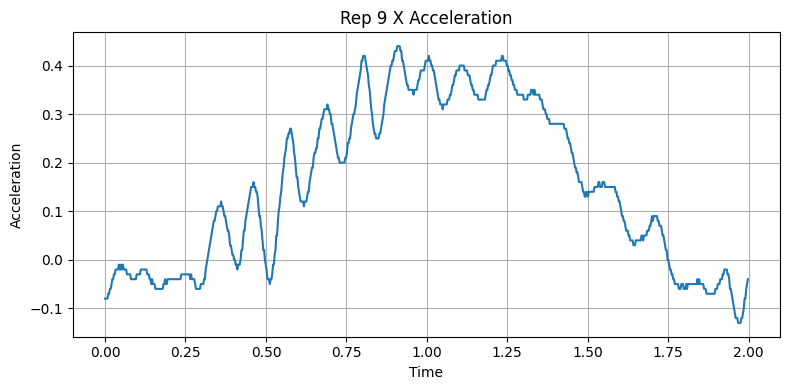

Rep 10: length=768, first 5 values=[-0.07 -0.07 -0.07 -0.07 -0.06]


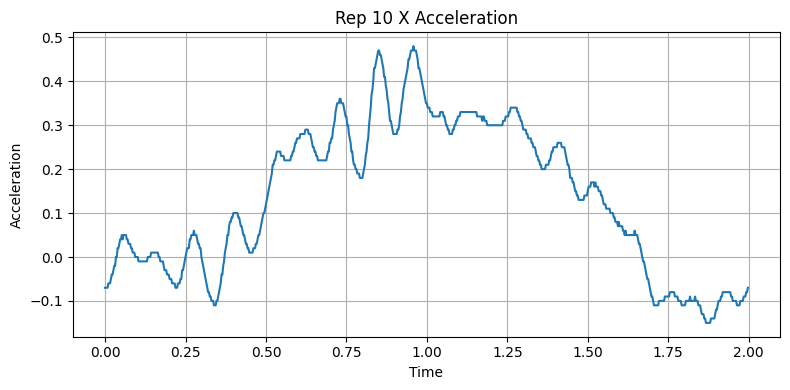

Rep 11: length=108, first 5 values=[-0.08 -0.08 -0.08 -0.08 -0.08]


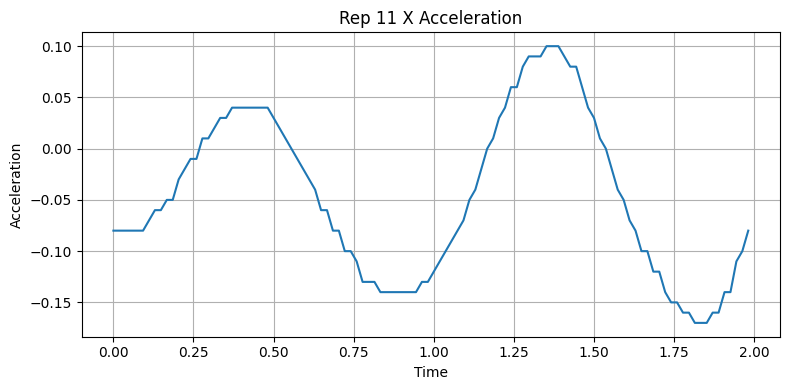

Rep 12: length=610, first 5 values=[-0.08 -0.06 -0.05 -0.02 -0.01]


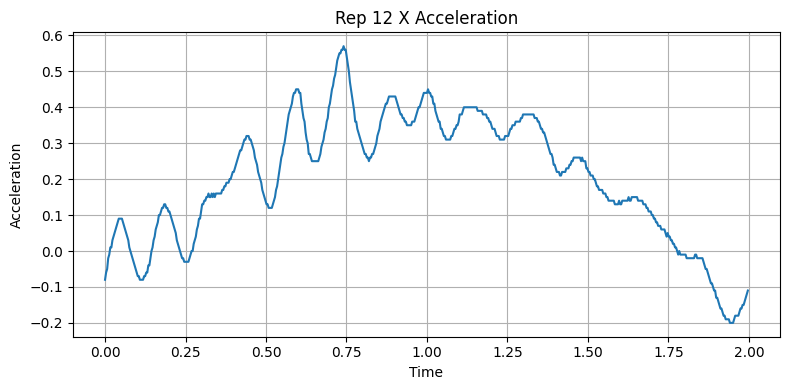

Rep 13: length=788, first 5 values=[-0.11 -0.11 -0.1  -0.1  -0.08]


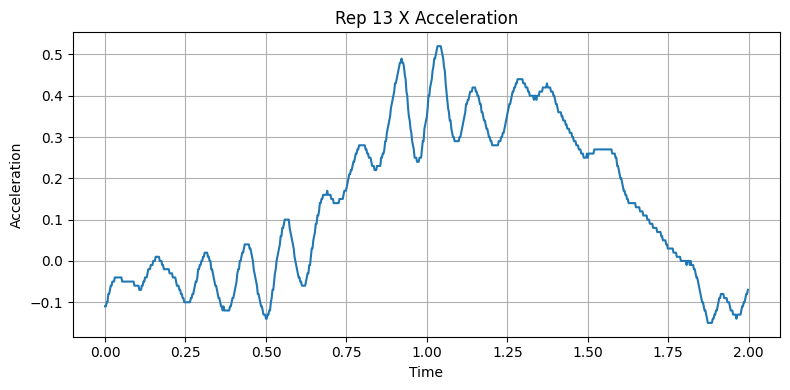

: 

In [ ]:
for i, rep in enumerate(out):
    print(f"Rep {i}: length={len(rep)}, first 5 values={rep[:5]}")
    plot_acceleration(rep, len(rep), 2, f"Rep {i} X Acceleration")